<a href="https://colab.research.google.com/github/PihuCodeTech/Aircraft-Engine-RUL-Prediction/blob/main/notebooks/BiLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np, random, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor
import tensorflow as tf
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

SEQ_LEN = 40

DATASET_CONFIG = {
    'FD001': {'rul_threshold':125, 'multi_condition':False},
    'FD002': {'rul_threshold':125, 'multi_condition':True},
    'FD003': {'rul_threshold':125, 'multi_condition':False},
    'FD004': {'rul_threshold':125, 'multi_condition':True},
}

# ── Change this path to where your files are ──────────────────────────────────
DATA_PATH = '/content/'   # Colab: files uploaded to content folder
# DATA_PATH = './'        # if files are in same folder as notebook

def load_data(dataset):
    cols     = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
    train_df = pd.read_csv(f"{DATA_PATH}train_{dataset}.txt",
                           sep=r"\s+", header=None)
    train_df.columns = cols
    test_df  = pd.read_csv(f"{DATA_PATH}test_{dataset}.txt",
                           sep=r"\s+", header=None)
    test_df.columns  = cols
    y_test   = pd.read_csv(f"{DATA_PATH}RUL_{dataset}.txt",
                           header=None).values.flatten()
    return train_df, test_df, y_test

#def mlp_condition_normalize(train_df, test_df, sensor_cols):
    train_df = train_df.copy(); test_df = test_df.copy()
    for col in sensor_cols:
        mlp = MLPRegressor(hidden_layer_sizes=(16,), max_iter=500,
                           random_state=SEED, alpha=0.01)
        mlp.fit(train_df[['op1','op2','op3']], train_df[col])
        train_df[col] = train_df[col] - mlp.predict(train_df[['op1','op2','op3']])
        test_df[col]  = test_df[col]  - mlp.predict(test_df[['op1','op2','op3']])
    return train_df, test_df

def preprocess(train_df, test_df, dataset):
    cfg = DATASET_CONFIG[dataset]
    max_cycle         = train_df.groupby('id')['cycle'].max().reset_index()
    max_cycle.columns = ['id','max_cycle']
    train_df          = train_df.merge(max_cycle, on='id')
    train_df['RUL']   = (train_df['max_cycle'] - train_df['cycle']).clip(upper=cfg['rul_threshold'])
    train_df.drop(columns=['max_cycle'], inplace=True)
    feature_cols = [c for c in train_df.columns if c not in ['id','RUL']]
    sensor_cols  = [c for c in feature_cols if c.startswith('s')]
    #if cfg['multi_condition']:
        #train_df, test_df = mlp_condition_normalize(train_df, test_df, sensor_cols)
    scaler = MinMaxScaler(feature_range=(0,1))
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df[feature_cols]  = scaler.transform(test_df[feature_cols])
    return train_df, test_df, feature_cols

def create_sequences(df, feature_cols, seq_len):
    X_seqs, y_seqs = [], []
    for eid in df['id'].unique():
        data = df[df['id'] == eid][feature_cols + ['RUL']].values
        for i in range(len(data) - seq_len):
            X_seqs.append(data[i:i+seq_len, :-1])
            y_seqs.append(data[i+seq_len, -1])
    return np.array(X_seqs, dtype=np.float32), np.array(y_seqs, dtype=np.float32)

def create_test_sequences(test_df, feature_cols, seq_len):
    X_test = []
    for eid in test_df['id'].unique():
        ed = test_df[test_df['id'] == eid][feature_cols].values
        if len(ed) < seq_len:
            pad = np.zeros((seq_len - len(ed), ed.shape[1]))
            ed  = np.vstack([pad, ed])
        else:
            ed  = ed[-seq_len:]
        X_test.append(ed)
    return np.array(X_test, dtype=np.float32)

def nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    return float(np.sum(np.where(diff < 0, np.exp(-diff/13)-1, np.exp(diff/10)-1)))

def report_metrics(name, true, pred):
    mse  = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(true, pred)
    nasa = nasa_score(true, pred)
    print(f"{name:40s} MSE={mse:.3f} RMSE={rmse:.3f} MAE={mae:.3f} NASA={nasa:.1f}")
    return rmse, mae, mse, nasa

def plot_loss(h, name, ds):
    plt.figure(figsize=(10,5))
    plt.plot(h.history['loss'],     label='Train Loss')
    plt.plot(h.history['val_loss'], label='Val Loss')
    plt.title(f'{name} — Loss vs Epoch ({ds})')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(); plt.show()

def plot_predictions(y_test, pred, name, ds):
    plt.figure(figsize=(14,5))
    plt.plot(y_test, label='Actual RUL', linewidth=2, color='black')
    plt.plot(pred,   label=f'{name} Predicted', linewidth=1.5,
             color='blue', alpha=0.8)
    plt.title(f'Actual vs Predicted RUL — {name} ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('RUL')
    plt.legend(); plt.grid(); plt.show()

def plot_residuals(y_test, pred, name, ds):
    res = y_test - pred
    plt.figure(figsize=(10,4))
    plt.scatter(range(len(res)), res, alpha=0.6, color='steelblue')
    plt.axhline(0, linestyle='--', color='black')
    plt.title(f'Residuals — {name} ({ds})')
    plt.xlabel('Engine Index'); plt.ylabel('Residual')
    plt.grid(); plt.show()

def plot_rmse_bar(results_dict, model_name):
    datasets  = list(results_dict.keys())
    rmse_vals = [results_dict[ds]['rmse'] for ds in datasets]
    plt.figure(figsize=(8,5))
    bars = plt.bar(datasets, rmse_vals, color='steelblue', edgecolor='white')
    plt.bar_label(bars, fmt='%.3f', padding=3)
    plt.title(f'{model_name} — Test RMSE Across Datasets')
    plt.ylabel('RMSE'); plt.grid(axis='y'); plt.show()

def plot_rul_dist(train_df, ds):
    plt.figure(figsize=(10,5))
    plt.hist(train_df['RUL'], bins=40, color='steelblue', edgecolor='white')
    plt.title(f'RUL Distribution — {ds}')
    plt.xlabel('RUL'); plt.ylabel('Frequency')
    plt.grid(); plt.show()

# Quick check that files load correctly
print("Testing data loading...")
for ds in ['FD001','FD002','FD003','FD004']:
    tr, te, y = load_data(ds)
    print(f"  {ds}: train={tr.shape} test={te.shape} y_test={y.shape}")
print("All datasets loaded successfully.")

Testing data loading...
  FD001: train=(20631, 26) test=(13096, 26) y_test=(100,)
  FD002: train=(53759, 26) test=(33991, 26) y_test=(259,)
  FD003: train=(24720, 26) test=(16596, 26) y_test=(100,)
  FD004: train=(61249, 26) test=(41214, 26) y_test=(248,)
All datasets loaded successfully.



███████████████████████████████████████████████████████
  Transformer | FD001
███████████████████████████████████████████████████████


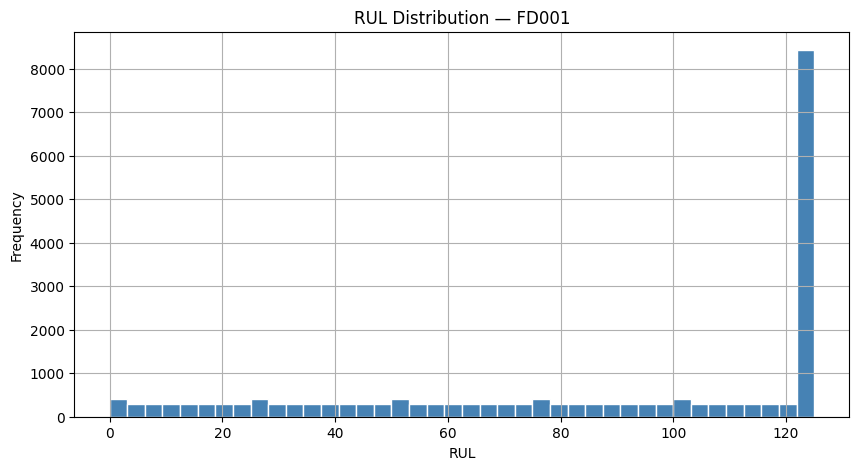

  Train:(13361, 40, 25) Val:(3270, 40, 25) Test:(100, 40, 25)

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

  Validation:
  Transformer                            MSE=158.427 RMSE=12.587 MAE=8.403 NASA=9717.6
  Test:
  Transformer                            MSE=257.876 RMSE=16.059 MAE=11.690 NASA=380.5


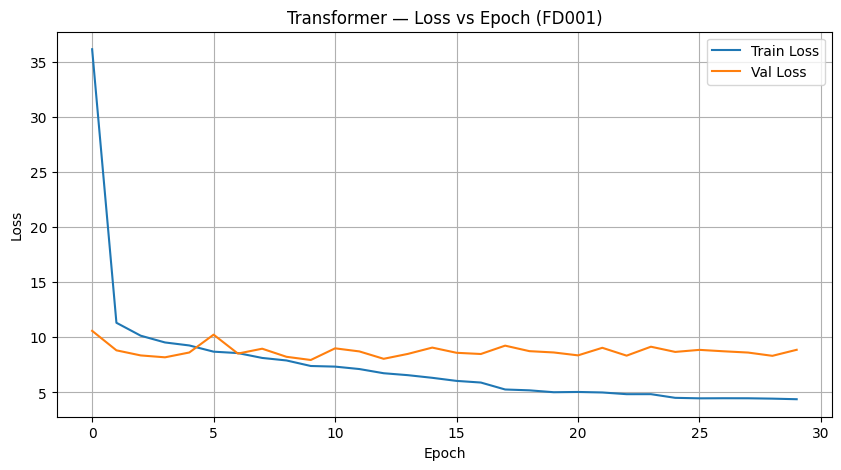

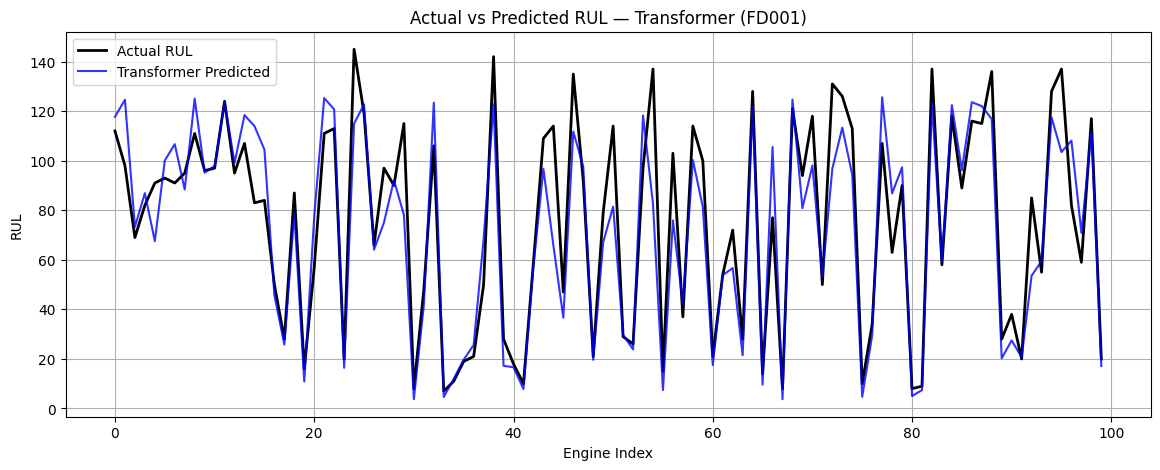

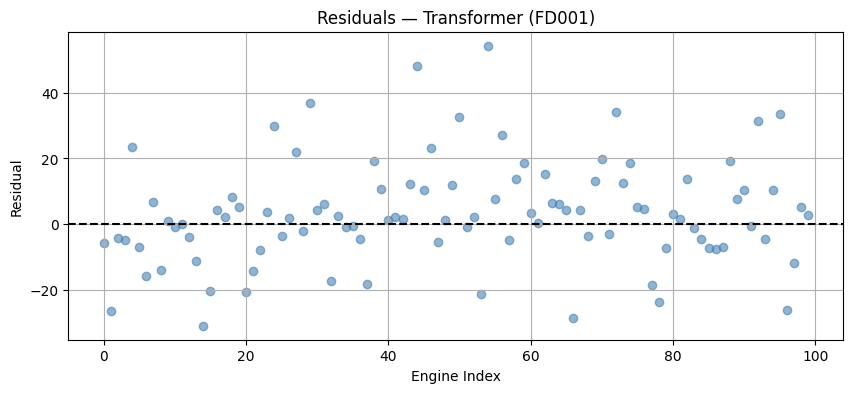


███████████████████████████████████████████████████████
  Transformer | FD002
███████████████████████████████████████████████████████


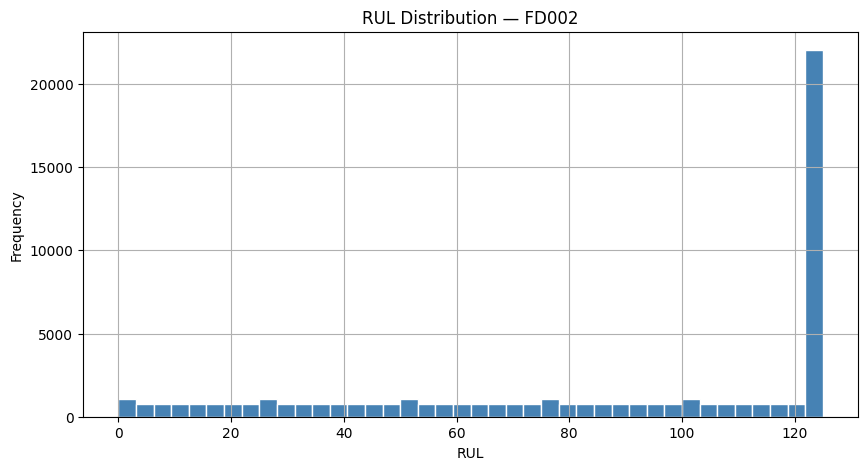

  Train:(35144, 40, 25) Val:(8215, 40, 25) Test:(259, 40, 25)

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

  Validation:
  Transformer                            MSE=258.674 RMSE=16.083 MAE=10.964 NASA=64413.8
  Test:
  Transformer                            MSE=662.609 RMSE=25.741 MAE=17.660 NASA=6011.9


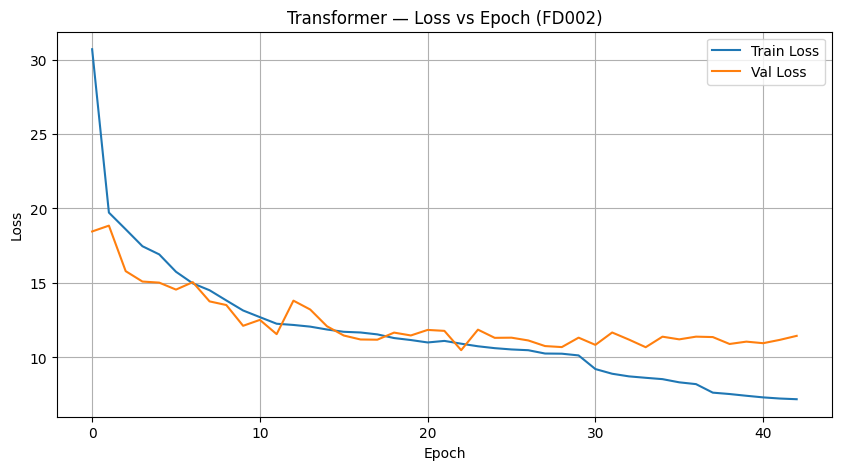

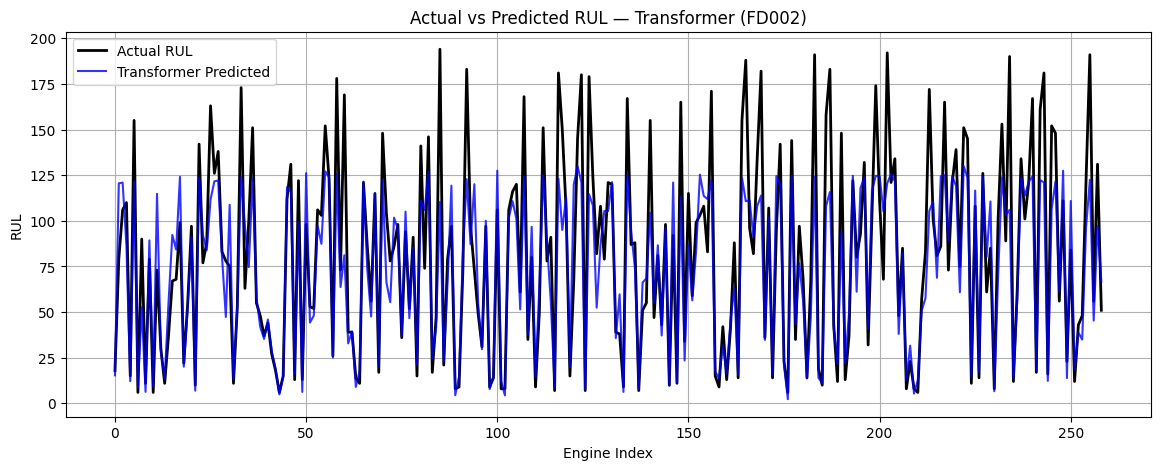

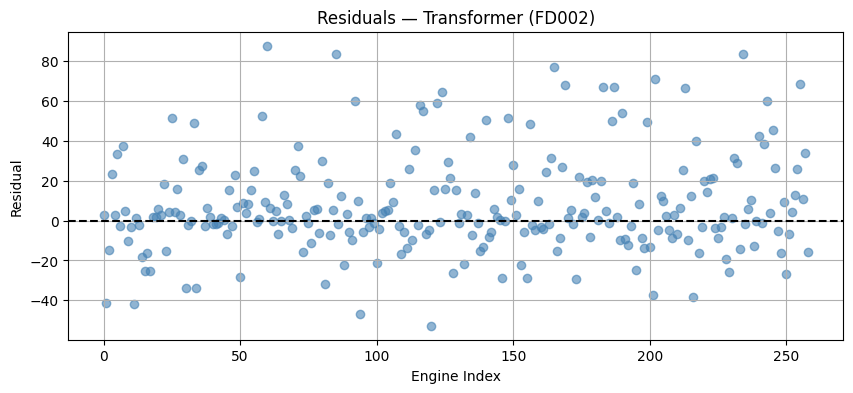


███████████████████████████████████████████████████████
  Transformer | FD003
███████████████████████████████████████████████████████


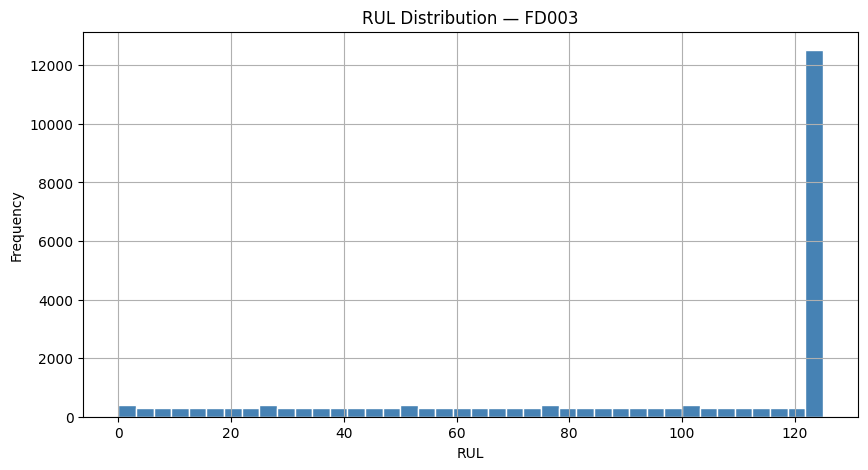

  Train:(16812, 40, 25) Val:(3908, 40, 25) Test:(100, 40, 25)

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

  Validation:
  Transformer                            MSE=100.846 RMSE=10.042 MAE=6.032 NASA=8392.0
  Test:
  Transformer                            MSE=241.852 RMSE=15.552 MAE=11.049 NASA=559.3


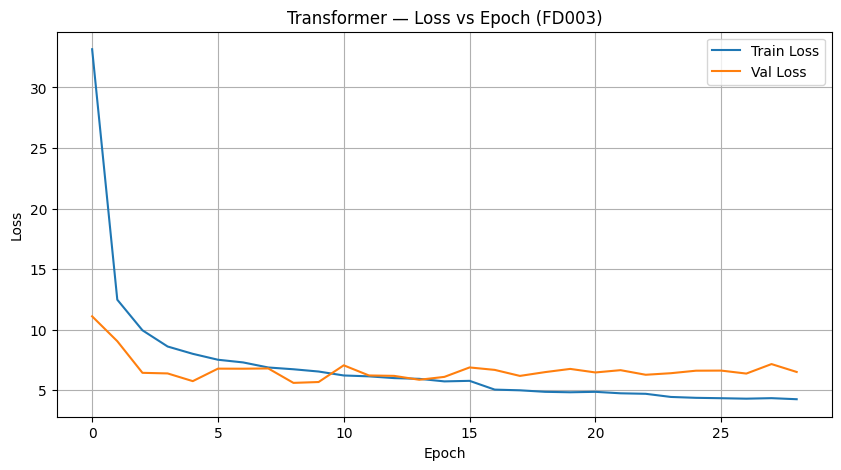

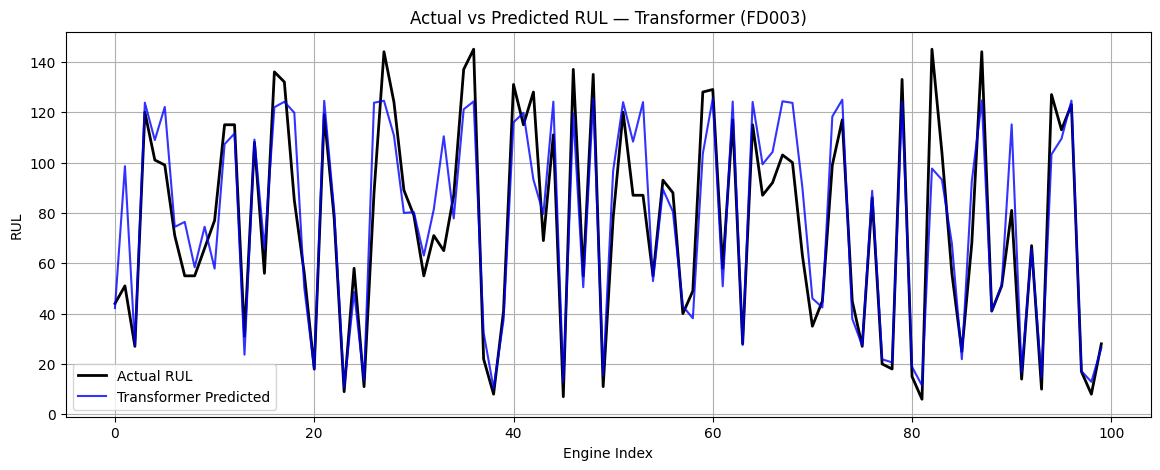

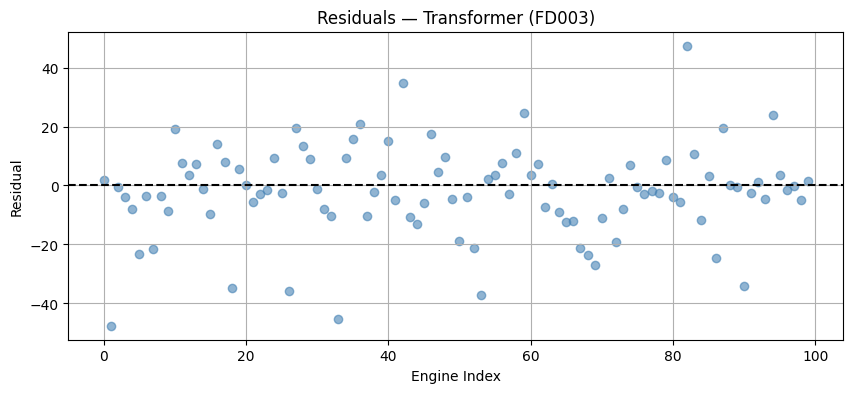


███████████████████████████████████████████████████████
  Transformer | FD004
███████████████████████████████████████████████████████


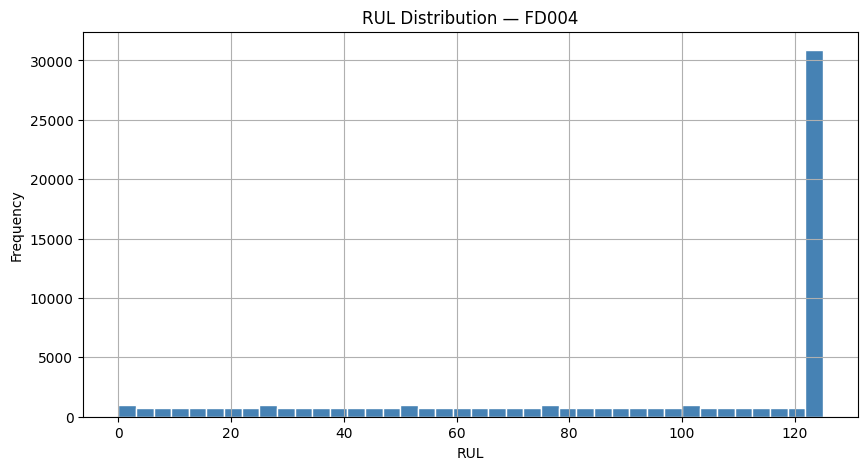

  Train:(41334, 40, 25) Val:(9955, 40, 25) Test:(248, 40, 25)

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 51: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 58: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

  Validation:
  Transformer                            MSE=361.166 RMSE=19.004 MAE=11.646 NASA=151248.5
  Test:
  Transformer                            MSE=670.122 RMSE=25.887 MAE=17.867 NASA=4508.8


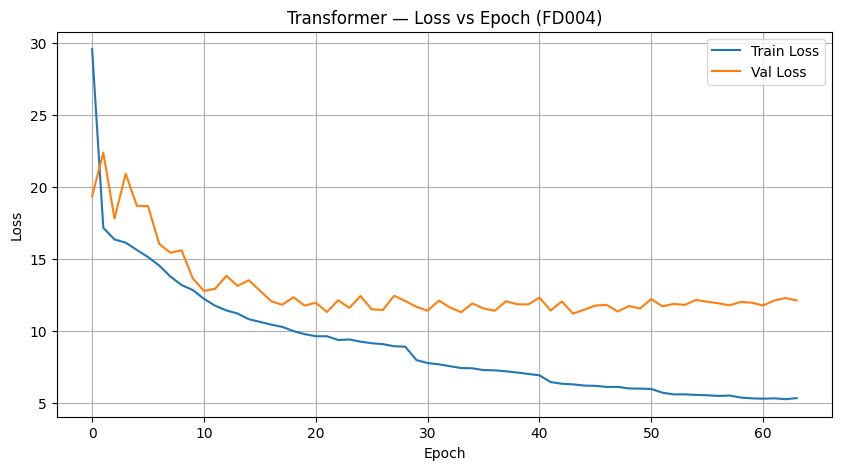

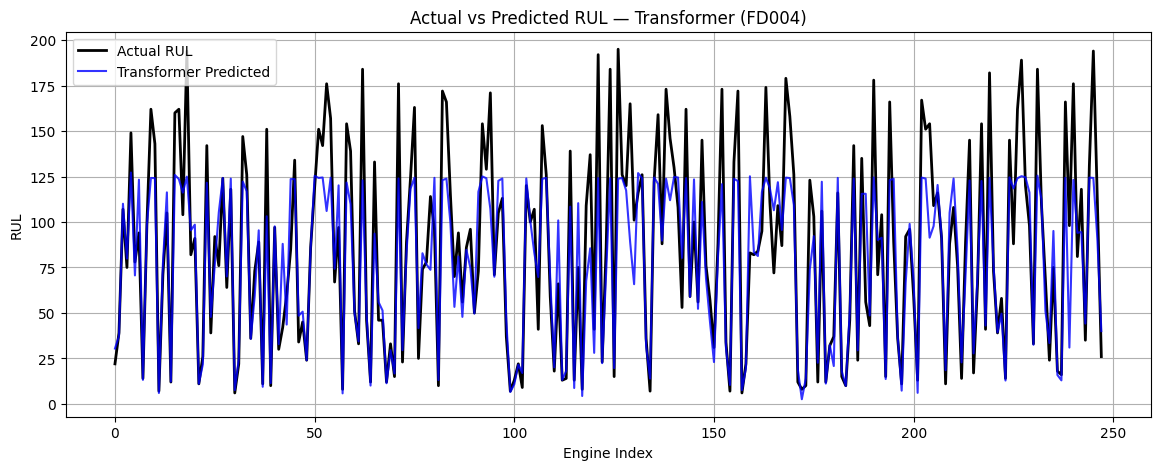

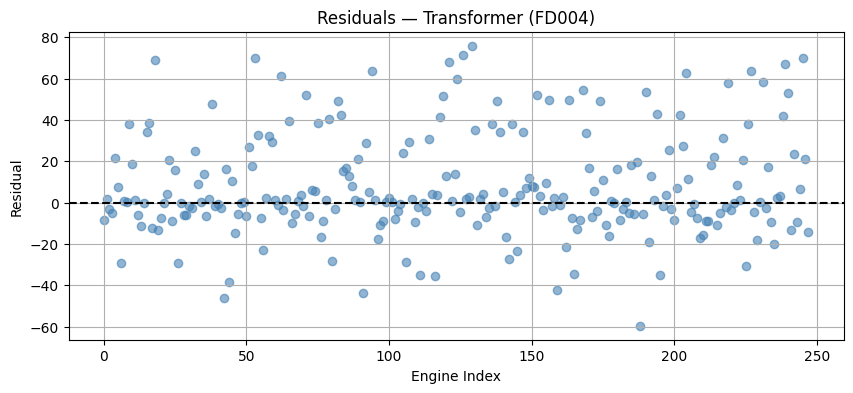


════════════════════════════════════════════════════════════
  Transformer FINAL RESULTS
════════════════════════════════════════════════════════════
Dataset        RMSE      MAE        MSE       NASA
────────── ──────── ──────── ────────── ──────────
FD001        16.059   11.690    257.876      380.5
FD002        25.741   17.660    662.609     6011.9
FD003        15.552   11.049    241.852      559.3
FD004        25.887   17.867    670.122     4508.8


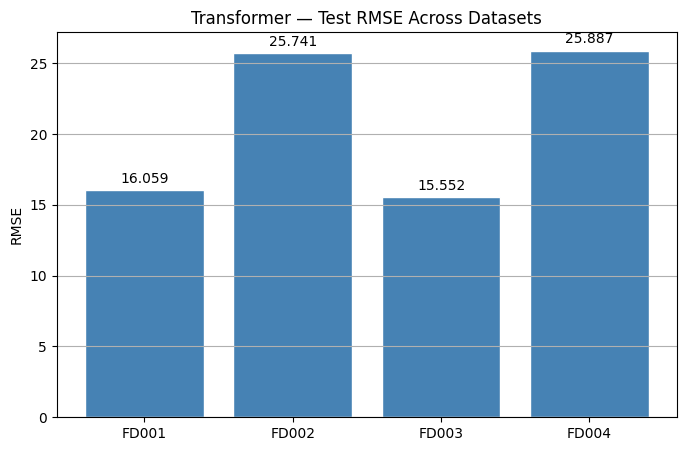


  HP: {'d_model': 64, 'num_heads': 4, 'num_layers': 3, 'ff_dim': 128, 'dropout': 0.1, 'dense_units': 64, 'lr': 0.0005, 'batch_size': 32, 'epochs': 100, 'patience_es': 20, 'patience_lr': 7, 'lr_factor': 0.5, 'min_lr': 1e-07}


In [3]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout,
    GlobalAveragePooling1D, LayerNormalization,
    MultiHeadAttention, Add
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber

MODEL_NAME = 'Transformer'

HP = {
    'd_model'     : 64,
    'num_heads'   : 4,
    'num_layers'  : 3,
    'ff_dim'      : 128,
    'dropout'     : 0.1,
    'dense_units' : 64,
    'lr'          : 5e-4,
    'batch_size'  : 32,
    'epochs'      : 100,
    'patience_es' : 20,
    'patience_lr' : 7,
    'lr_factor'   : 0.5,
    'min_lr'      : 1e-7,
}

def transformer_block(x, d_model, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads,
                              key_dim=d_model//num_heads,
                              dropout=dropout)(x, x)
    x    = LayerNormalization()(Add()([x, attn]))
    ffn  = Dense(ff_dim, activation='relu')(x)
    ffn  = Dense(d_model)(ffn)
    return LayerNormalization()(Add()([x, ffn]))

def build_transformer(seq_len, n_features):
    inputs    = Input(shape=(seq_len, n_features))
    x         = Dense(HP['d_model'])(inputs)
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_emb   = tf.keras.layers.Embedding(seq_len, HP['d_model'])(positions)
    x         = x + pos_emb
    for _ in range(HP['num_layers']):
        x = transformer_block(x, HP['d_model'], HP['num_heads'],
                              HP['ff_dim'], HP['dropout'])
    x       = GlobalAveragePooling1D()(x)
    x       = Dense(HP['dense_units'], activation='relu')(x)
    x       = Dropout(HP['dropout'])(x)
    outputs = Dense(1)(x)
    model   = Model(inputs, outputs)
    model.compile(optimizer=Adam(HP['lr'], clipnorm=1.0),
                  loss=Huber(), metrics=['mae'])
    return model

def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=HP['patience_es'],
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=HP['lr_factor'],
                          patience=HP['patience_lr'],
                          min_lr=HP['min_lr'], verbose=1)
    ]

DATASETS    = ['FD001','FD002','FD003','FD004']
all_results = {}

for dataset in DATASETS:
    print(f"\n{'█'*55}\n  {MODEL_NAME} | {dataset}\n{'█'*55}")

    train_raw, test_raw, y_test = load_data(dataset)
    train_df, test_df, feature_cols = preprocess(
        train_raw.copy(), test_raw.copy(), dataset)
    plot_rul_dist(train_df, dataset)

    eids             = train_df['id'].unique()
    tr_e, val_e      = train_test_split(eids, test_size=0.2, random_state=SEED)
    X_train, y_train = create_sequences(
        train_df[train_df['id'].isin(tr_e)], feature_cols, SEQ_LEN)
    X_val,   y_val   = create_sequences(
        train_df[train_df['id'].isin(val_e)], feature_cols, SEQ_LEN)
    X_test_seq       = create_test_sequences(test_df, feature_cols, SEQ_LEN)
    nf               = X_train.shape[2]

    print(f"  Train:{X_train.shape} Val:{X_val.shape} Test:{X_test_seq.shape}")

    model = build_transformer(SEQ_LEN, nf)
    hist  = model.fit(X_train, y_train,
                      validation_data=(X_val, y_val),
                      epochs=HP['epochs'],
                      batch_size=HP['batch_size'],
                      callbacks=get_callbacks(),
                      verbose=0)

    vp = model.predict(X_val,      verbose=0).flatten()
    tp = model.predict(X_test_seq, verbose=0).flatten()

    print("\n  Validation:")
    report_metrics(f"  {MODEL_NAME}", y_val, vp)
    print("  Test:")
    r,m,ms,n = report_metrics(f"  {MODEL_NAME}", y_test, tp)
    all_results[dataset] = {'rmse':r,'mae':m,'mse':ms,'nasa':n}

    plot_loss(hist, MODEL_NAME, dataset)
    plot_predictions(y_test, tp, MODEL_NAME, dataset)
    plot_residuals(y_test, tp, MODEL_NAME, dataset)

print(f"\n{'═'*60}\n  {MODEL_NAME} FINAL RESULTS\n{'═'*60}")
print(f"{'Dataset':<10} {'RMSE':>8} {'MAE':>8} {'MSE':>10} {'NASA':>10}")
print(f"{'':─<10} {'':─>8} {'':─>8} {'':─>10} {'':─>10}")
for ds in DATASETS:
    r = all_results[ds]
    print(f"{ds:<10} {r['rmse']:>8.3f} {r['mae']:>8.3f} "
          f"{r['mse']:>10.3f} {r['nasa']:>10.1f}")

plot_rmse_bar(all_results, MODEL_NAME)
print(f"\n  HP: {HP}")